In [10]:
# 1. Import make_blobs dataset ✅
# 2. Code a random classifier ✅
# 3. Explore ROC and AUC functions ✅

In [11]:
from sklearn.datasets import make_blobs 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import torch

Text(0.5, 1.0, 'Dataset Visualization')

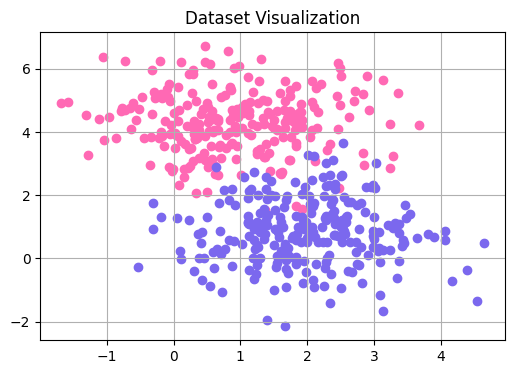

In [12]:
x, y = make_blobs(n_samples=500, centers=2, n_features=2, random_state=0)
plt.figure(figsize=(6, 4))
plt.scatter(x[:, 0][y==0], x[:, 1][y==0], color="hotpink");
plt.scatter(x[:, 0][y==1], x[:, 1][y==1], color="MediumSlateBlue");
plt.grid()
plt.title("Dataset Visualization")

In [13]:
torch.manual_seed(10)
class ClassifierNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.layer1 = nn.Linear(2, 6)
        self.layer2 = nn.Linear(6, 3)
        self.output_layer = nn.Linear(3, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.flatten(x)
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        x = self.relu(x)
        x = self.output_layer(x)
        x = self.sigmoid(x)
        return x

In [14]:
model = ClassifierNN()
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.BCELoss()
epochs = 300

def training_loop(x_train, y_train, x_val, y_val, epochs):
    loss_records = {
        "training": [],
        "validation": [],
    }

    for epoch in range(epochs):
        model.train()

        # forward pass
        y_pred = model(x_train)

        # loss
        loss = criterion(y_pred, y_train)
        loss_records["training"].append(loss.item())

        # backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # validation
        model.eval()
        with torch.no_grad():
            y_pred_val = model(x_val)
            loss_val = criterion(y_pred_val, y_val)
            loss_records["validation"].append(loss_val.item())

    return loss_records


In [15]:
x_train, x_val_test, y_train, y_val_test = train_test_split(x, y, test_size=0.5, random_state=0)
x_val, x_test, y_val, y_test = train_test_split(x_val_test, y_val_test, test_size=0.5, random_state=4)

def to_tensor(array):
    array = torch.tensor(array, dtype=torch.float32)
    return array

x_train = to_tensor(x_train)
x_test = to_tensor(x_test)
x_val = to_tensor(x_val)
y_train = to_tensor(y_train).view(-1, 1)
y_test = to_tensor(y_test).view(-1, 1)
y_val = to_tensor(y_val).view(-1, 1)

Text(0.5, 1.0, 'Training and Validation Losses')

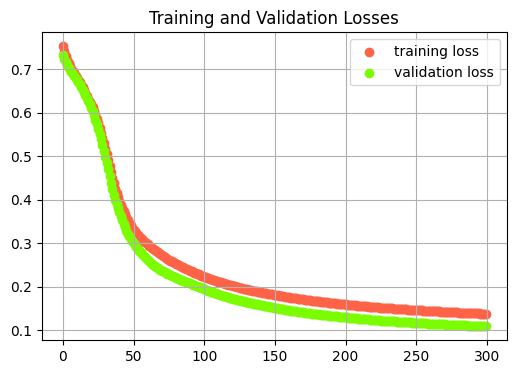

In [16]:
losses = training_loop(x_train, y_train, x_val, y_val, epochs)

plt.figure(figsize=(6, 4))
plt.scatter(range(epochs), losses["training"], color="Tomato", label="training loss");
plt.scatter(range(epochs), losses["validation"], color="LawnGreen", label="validation loss");
plt.legend()
plt.grid()
plt.title("Training and Validation Losses")


Text(0.5, 1.0, 'ROC Curve')

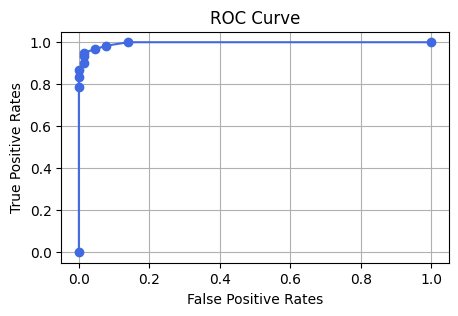

In [17]:
def roc_curve():
    tprs = []
    fprs = []

    with torch.no_grad():
        y_probs = model(x_test)
        for th in np.arange(0, 1.1, 0.1):
            y_preds = (y_probs > th).float()
            tp = ((y_test==1) & (y_preds==1)).sum()
            fn = ((y_test==1) & (y_preds==0)).sum()
            fp = ((y_test==0) & (y_preds==1)).sum()
            tn = ((y_test==0) & (y_preds==0)).sum()

            # true positive rates
            tpr = tp / (tp + fn)
            tprs.append(tpr)

            # false positive rates
            fpr = fp / (fp + tn)
            fprs.append(fpr)

    return tprs, fprs

tprs, fprs = roc_curve()

plt.figure(figsize=(5, 3))
plt.plot(fprs, tprs, color="RoyalBlue", marker='o');
plt.xlabel("False Positive Rates")
plt.ylabel("True Positive Rates")
plt.grid()
plt.title("ROC Curve")

Text(0.5, 1.0, 'AUC Curve')

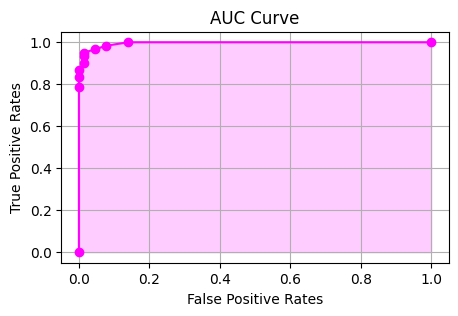

In [18]:
plt.figure(figsize=(5, 3))
plt.fill_between(fprs, tprs, alpha=0.2, color="Fuchsia");
plt.plot(fprs, tprs, marker='o', color="Fuchsia");
plt.xlabel("False Positive Rates")
plt.ylabel("True Positive Rates")
plt.grid()
plt.title("AUC Curve")

##### In conclusion we created a classifier using make_blobs, graphed ROC and AUC curves, evaluating the model's performance. ROC curve is created by calculating True Positive Rates(recall/sensitivity) & False Positive Rates(false alarm rate) at all thresholds. The closer the area under curve to 1, the better are the results.